In [10]:
#Adapted from LIF_sim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

__all__ = ["lif_sim"]


def lif_sim(I=1.1, T=30.0, dt=1e-3, taum=10.0, R=1.0, urest=0.0, uth=1.0):
    """Integrate the LIF model using the Euler scheme.

    I     : constant current or time-dependent function I(t)
    Returns: t, u, spikes
    """
    Ifun = I if callable(I) else (lambda t: I)
    nt = int(round(T / dt)) + 1
    t = np.linspace(0.0, T, nt)
    u = np.zeros(nt)
    u[0] = urest
    spikes = []

    for j in range(nt - 1):
        du = dt * (R * Ifun(t[j]) - (u[j] - urest)) / taum
        u[j + 1] = u[j] + du
        if u[j + 1] >= uth:
            spikes.append(t[j + 1])
            u[j + 1] = urest  # Voltage reset rule

    return t, u, np.array(spikes)








=== Analytical Key Outputs ===
t_peak  = 4.0236 ms
Icrit_0 = 7.4767

=== Numerical Simulation Results ===
Condition                      | I0       | Num t_peak (ms)  | Num Peak Voltage (mV) 
----------------------------------------------------------------------------------
0.8 * Icrit_0 (Subthreshold)   | 5.9814   | 4.0240           | 0.8002                
1.0 * Icrit_0 (Threshold)      | 7.4767   | 4.0240           | 1.0003                
1.2 * Icrit_0 (Superthreshold) | 8.9721   | 4.0240           | 1.2003                


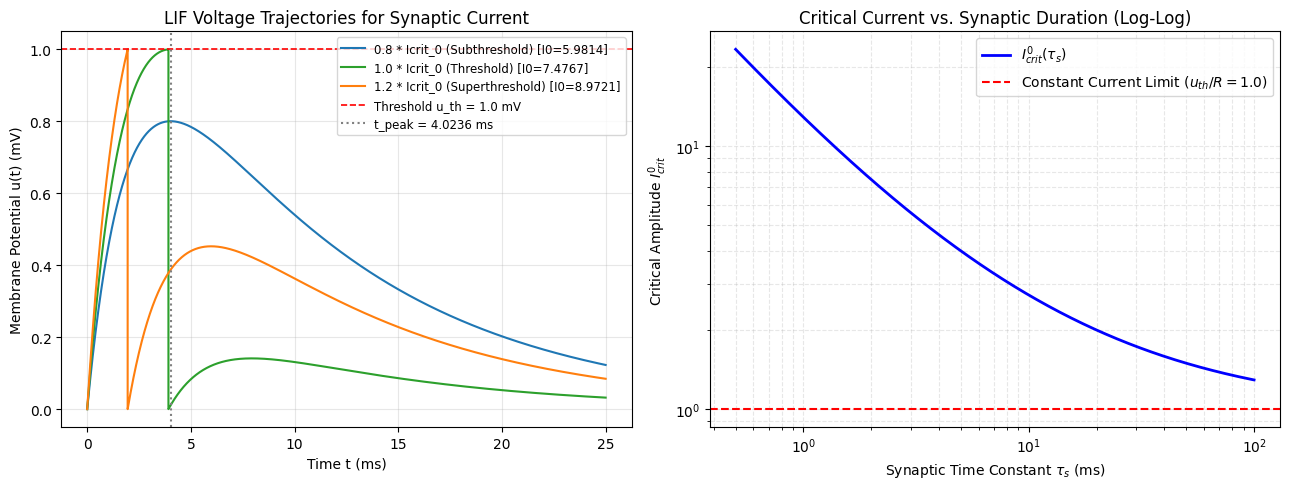

In [14]:
 if __name__ == "__main__":
    # --- Parameters ---
    R = 1.0         # Ohm
    taum = 10.0     # ms
    taus = 2.0      # ms
    urest = 0.0     # mV
    uth = 1.0       # mV
    dt = 1e-3       # ms resolution
 # --- Analytical Values ---
    r = taus / taum
    t_peak = (taum * taus / (taus - taum)) * np.log(taus / taum)
    I_crit_0 = (uth / R) * (r ** (1.0 / (r - 1.0)))

    print("=== Analytical Key Outputs ===")
    print(f"t_peak  = {t_peak:.4f} ms")
    print(f"Icrit_0 = {I_crit_0:.4f}\n")

    # Amplitudes to simulate: below, at, and above Icrit_0
    amps = [0.8 * I_crit_0, 1.0 * I_crit_0, 1.2 * I_crit_0]
    amp_labels = ["0.8 * Icrit_0 (Subthreshold)",
                  "1.0 * Icrit_0 (Threshold)",
                  "1.2 * Icrit_0 (Superthreshold)"]
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e']

    print("=== Numerical Simulation Results ===")
    print(f"{'Condition':<30} | {'I0':<8} | {'Num t_peak (ms)':<16} | {'Num Peak Voltage (mV)':<22}")
    print("-" * 82)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    for I0, label, color in zip(amps, amp_labels, colors):
        synaptic_I = lambda t: I0 * np.exp(-t / taus)

        # Simulation with threshold reset
        t, u, spikes = lif_sim(I=synaptic_I, T=25.0, dt=dt, taum=taum, R=R, urest=urest, uth=uth)

        # Unreset simulation to measure the true unconstrained trajectory peak
        _, u_no_reset, _ = lif_sim(I=synaptic_I, T=25.0, dt=dt, taum=taum, R=R, urest=urest, uth=np.inf)

        num_peak = np.max(u_no_reset)
        num_t_peak = t[np.argmax(u_no_reset)]

        print(f"{label:<30} | {I0:<8.4f} | {num_t_peak:<16.4f} | {num_peak:<22.4f}")

        # Plot u(t)
        ax1.plot(t, u, label=f"{label} [I0={I0:.4f}]", color=color, lw=1.5)

    # Decorate Plot 1
    ax1.axhline(uth, color="red", linestyle="--", linewidth=1.2, label=f"Threshold u_th = {uth:.1f} mV")
    ax1.axvline(t_peak, color="gray", linestyle=":", label=f"t_peak = {t_peak:.4f} ms")
    ax1.set_xlabel("Time t (ms)")
    ax1.set_ylabel("Membrane Potential u(t) (mV)")
    ax1.set_title("LIF Voltage Trajectories for Synaptic Current")
    ax1.legend(fontsize=8.5, loc="upper right")
    ax1.grid(True, alpha=0.3)

    # -------------------------------------------------------------
    # Plot 2: Log-Log Plot of Icrit_0 vs tau_s in [0.5, 100] ms
    # -------------------------------------------------------------
    taus_range = np.logspace(np.log10(0.5), np.log10(100.0), 500)
    r_range = taus_range / taum
    I_crit_range = (uth / R) * (r_range ** (1.0 / (r_range - 1.0)))

    ax2.loglog(taus_range, I_crit_range, "b-", lw=2, label="$I_{crit}^0(\\tau_s)$")
    ax2.axhline(uth / R, color="r", linestyle="--", label="Constant Current Limit ($u_{th}/R = 1.0$)")
    ax2.set_xlabel("Synaptic Time Constant $\\tau_s$ (ms)")
    ax2.set_ylabel("Critical Amplitude $I_{crit}^0$")
    ax2.set_title("Critical Current vs. Synaptic Duration (Log-Log)")
    ax2.legend()
    ax2.grid(True, which="both", ls="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


The two limits are as taus goes to 0 and taus goes to infinity. In the case taus goes to infinity, the current reduces to the constant current answer (I0=(uth-urest)/R). This occurs because the decay rate rapidly reduces so the system behaves like a constant input current is being fed. As taus goes to zero, I0 goes to 0 at a fast impulse limit.